# Part 4: Evaluation — Perplexity Measurement

Evaluate the base model and the LoRA-adapted model on the held-out validation set.

**Main metric**: Perplexity (https://huggingface.co/docs/transformers/perplexity)

$$\text{PPL} = \exp\left(-\frac{1}{N} \sum_{i=1}^{N} \log P(x_i | x_{<i})\right)$$

Lower perplexity = better model fit to the text.

In [1]:
import os, sys, json
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import PeftModel
from tqdm import tqdm

print(f"Python: {sys.version}")
print(f"CWD: {os.getcwd()}")
print(f'PyTorch: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        props = torch.cuda.get_device_properties(i)
        print(f"  GPU {i}: {props.name}, {props.total_memory / 1024**3:.1f} GB")

c:\Users\BeRo074\OneDrive - HP Inc\Desktop\second_degree - BGU\LLM models\assignment1\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Python: 3.10.0rc2 (tags/v3.10.0rc2:839d789, Sep  7 2021, 18:51:45) [MSC v.1929 64 bit (AMD64)]
CWD: c:\Users\BeRo074\OneDrive - HP Inc\Desktop\second_degree - BGU\LLM models\assignment1
PyTorch: 2.11.0+cu128
CUDA available: True
  GPU 0: NVIDIA RTX A1000 6GB Laptop GPU, 6.0 GB


In [6]:
# Set up project directory on remote server & check what's needed
PROJECT_DIR = Path('/storage/Users/llm_assignment')
DATA_DIR_REMOTE = PROJECT_DIR / 'data' / 'processed'
ADAPTER_DIR_REMOTE = PROJECT_DIR / 'outputs' / 'baseline' / 'final_adapter'

DATA_DIR_REMOTE.mkdir(parents=True, exist_ok=True)
ADAPTER_DIR_REMOTE.mkdir(parents=True, exist_ok=True)

needed = []
for f in ['val_raw.txt', 'train.jsonl', 'val.jsonl', 'metadata.json']:
    if not (DATA_DIR_REMOTE / f).exists():
        needed.append(f)
for f in ['adapter_config.json', 'adapter_model.safetensors', 'tokenizer_config.json', 'tokenizer.json']:
    if not (ADAPTER_DIR_REMOTE / f).exists():
        needed.append(f)

if needed:
    print(f"Files needed on remote: {needed}")
else:
    print("All files already present on remote server!")

Files needed on remote: ['val_raw.txt', 'train.jsonl', 'val.jsonl', 'metadata.json', 'adapter_config.json', 'adapter_model.safetensors', 'tokenizer_config.json', 'tokenizer.json']


In [8]:
# Re-download and preprocess data on the remote server
# This is faster than uploading since the server has internet access
import requests as req
import re

BOOKS = {
    'A Study in Scarlet': 244,
    'The Sign of the Four': 2097,
    'Adventures of Sherlock Holmes': 1661,
    'Memoirs of Sherlock Holmes': 834,
    'The Hound of the Baskervilles': 2852,
    'The Return of Sherlock Holmes': 108,
    'The Valley of Fear': 3289,
    'His Last Bow': 2350,
    'The Case-Book of Sherlock Holmes': 2868,
}

RAW_DIR = DATA_DIR_REMOTE.parent / 'raw'
RAW_DIR.mkdir(parents=True, exist_ok=True)

print("Downloading Sherlock Holmes corpus from Project Gutenberg...")
for title, gid in BOOKS.items():
    outfile = RAW_DIR / f'{title.replace(" ", "_")}.txt'
    if outfile.exists():
        print(f'  Already have: {title}')
        continue
    url = f'https://www.gutenberg.org/cache/epub/{gid}/pg{gid}.txt'
    resp = req.get(url)
    resp.raise_for_status()
    outfile.write_text(resp.text, encoding='utf-8')
    print(f'  Downloaded: {title} ({len(resp.text):,} chars)')

print("\nAll books downloaded!")

  Downloaded: A Study in Scarlet (263,857 chars)
  Downloaded: The Sign of the Four (256,330 chars)
  Downloaded: Adventures of Sherlock Holmes (593,912 chars)
  Downloaded: Memoirs of Sherlock Holmes (600,659 chars)
  Downloaded: The Hound of the Baskervilles (381,208 chars)
  Downloaded: The Return of Sherlock Holmes (706,850 chars)
  Downloaded: The Valley of Fear (340,175 chars)
  Downloaded: His Last Bow (350,371 chars)
  Downloaded: The Case-Book of Sherlock Holmes (521,910 chars)

All books downloaded!


In [11]:
# Preprocess corpus on the remote server (same logic as notebook 02)
from transformers import AutoTokenizer
import re

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# 1. Read and clean texts
raw_texts = {}
for title, gid in BOOKS.items():
    fname = RAW_DIR / f'{title.replace(" ", "_")}.txt'
    raw_texts[title] = fname.read_text(encoding='utf-8')

def clean_gutenberg(text):
    # Remove Project Gutenberg header/footer
    start_markers = ['*** START OF THE PROJECT GUTENBERG', '*** START OF THIS PROJECT GUTENBERG']
    end_markers = ['*** END OF THE PROJECT GUTENBERG', '*** END OF THIS PROJECT GUTENBERG',
                   '***END OF THE PROJECT GUTENBERG', 'End of the Project Gutenberg',
                   'End of Project Gutenberg']
    for m in start_markers:
        idx = text.find(m)
        if idx != -1:
            text = text[text.index('\n', idx) + 1:]
            break
    for m in end_markers:
        idx = text.find(m)
        if idx != -1:
            text = text[:idx]
            break
    # Clean formatting
    text = re.sub(r'_([^_]+)_', r'\1', text)  # Remove _emphasis_
    text = re.sub(r'\r\n', '\n', text)
    text = re.sub(r'\n{3,}', '\n\n', text)
    text = re.sub(r' {2,}', ' ', text)
    return text.strip()

cleaned = {title: clean_gutenberg(raw) for title, raw in raw_texts.items()}

# 2. Split validation set (The Sign of the Four)
val_source = 'The Sign of the Four'
val_text = cleaned[val_source]
train_texts = [cleaned[t] for t in cleaned if t != val_source]
train_corpus = '\n\n'.join(train_texts)

# 3. Tokenize and chunk
def chunk_text(text, tokenizer, max_length=512):
    tokens = tokenizer.encode(text)
    chunks = []
    for i in range(0, len(tokens), max_length):
        chunk_tokens = tokens[i:i + max_length]
        if len(chunk_tokens) >= max_length // 4:
            chunks.append(tokenizer.decode(chunk_tokens))
    return chunks

train_chunks = chunk_text(train_corpus, tokenizer, MAX_LENGTH)
val_chunks = chunk_text(val_text, tokenizer, MAX_LENGTH)

total_tokens = sum(len(tokenizer.encode(cleaned[t])) for t in cleaned)
val_tokens = len(tokenizer.encode(val_text))

print(f'Total corpus tokens: {total_tokens:,}')
print(f'Validation: {val_source} — {val_tokens:,} tokens ({val_tokens/total_tokens*100:.1f}%)')
print(f'Train chunks: {len(train_chunks)} (× {MAX_LENGTH} = ~{len(train_chunks) * MAX_LENGTH:,} tokens)')
print(f'Val chunks: {len(val_chunks)}')

# 4. Save processed data
import json as json_mod

# Save JSONL files
with open(DATA_DIR_REMOTE / 'train.jsonl', 'w', encoding='utf-8') as f:
    for chunk in train_chunks:
        f.write(json_mod.dumps({'text': chunk}) + '\n')

with open(DATA_DIR_REMOTE / 'val.jsonl', 'w', encoding='utf-8') as f:
    for chunk in val_chunks:
        f.write(json_mod.dumps({'text': chunk}) + '\n')

# Save raw validation text
(DATA_DIR_REMOTE / 'val_raw.txt').write_text(val_text, encoding='utf-8')

# Save metadata
metadata = {
    'model_name': MODEL_NAME, 'max_length': MAX_LENGTH,
    'num_train_chunks': len(train_chunks), 'num_val_chunks': len(val_chunks),
    'total_train_tokens': len(train_chunks) * MAX_LENGTH,
    'val_tokens': val_tokens, 'val_source': val_source,
}
with open(DATA_DIR_REMOTE / 'metadata.json', 'w') as f:
    json_mod.dump(metadata, f, indent=2)

print(f'\nData saved to {DATA_DIR_REMOTE}')
del tokenizer  # Free memory before loading model

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (819588 > 131072). Running this sequence through the model will result in indexing errors


Total corpus tokens: 877,076
Validation: The Sign of the Four — 57,489 tokens (6.6%)
Train chunks: 1601 (× 512 = ~819,712 tokens)
Val chunks: 113

Data saved to /storage/Users/llm_assignment/data/processed


In [12]:
# ============================================================
# TRAIN on remote server (RTX 2080 Ti — much faster)
# ============================================================
from datasets import load_dataset
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training, TaskType
from trl import SFTTrainer, SFTConfig
import json as json_mod

# Config
LORA_R = 16
LORA_ALPHA = 32
LORA_DROPOUT = 0.05
LORA_TARGET_MODULES = ['q_proj', 'v_proj']
NUM_EPOCHS = 3
LEARNING_RATE = 2e-4
BATCH_SIZE = 4  # RTX 2080 Ti has 10.6 GB — can handle batch_size=4
GRADIENT_ACCUMULATION_STEPS = 4
WARMUP_RATIO = 0.05
LR_SCHEDULER = 'cosine'
WEIGHT_DECAY = 0.01
OUTPUT_DIR = ADAPTER_DIR_REMOTE.parent  # outputs/baseline
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

EXPERIMENT_NAME = f'sherlock_lora_r{LORA_R}_lr{LEARNING_RATE}'

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# Load model with QLoRA
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type='nf4',
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
)
print('Loading model with QLoRA...')
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    device_map='auto',
    dtype=torch.bfloat16,
)
model = prepare_model_for_kbit_training(model)
model.gradient_checkpointing_enable()

# Apply LoRA
lora_config = LoraConfig(
    r=LORA_R, lora_alpha=LORA_ALPHA, lora_dropout=LORA_DROPOUT,
    target_modules=LORA_TARGET_MODULES, bias='none', task_type=TaskType.CAUSAL_LM,
)
model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

# Load data
train_dataset = load_dataset('json', data_files=str(DATA_DIR_REMOTE / 'train.jsonl'), split='train')
val_dataset = load_dataset('json', data_files=str(DATA_DIR_REMOTE / 'val.jsonl'), split='train')
print(f'Train: {len(train_dataset)}, Val: {len(val_dataset)}')

# Training config
training_args = SFTConfig(
    output_dir=str(OUTPUT_DIR),
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    gradient_accumulation_steps=GRADIENT_ACCUMULATION_STEPS,
    learning_rate=LEARNING_RATE,
    lr_scheduler_type=LR_SCHEDULER,
    warmup_ratio=WARMUP_RATIO,
    weight_decay=WEIGHT_DECAY,
    logging_steps=10,
    save_steps=100,
    save_total_limit=3,
    eval_strategy='steps',
    eval_steps=100,
    bf16=True,
    gradient_checkpointing=True,
    max_length=MAX_LENGTH,
    dataset_text_field='text',
    report_to='tensorboard',
    run_name=EXPERIMENT_NAME,
    logging_dir=str(OUTPUT_DIR / 'logs'),
    seed=42,
    packing=True,
)

# Create trainer & train
trainer = SFTTrainer(
    model=model, args=training_args,
    train_dataset=train_dataset, eval_dataset=val_dataset,
    processing_class=tokenizer,
)

print(f'\nStarting training on {torch.cuda.get_device_name(0)}...')
train_result = trainer.train()

print(f'\n=== Training Complete ===')
print(f'Training loss: {train_result.training_loss:.4f}')
print(f'Training time: {train_result.metrics["train_runtime"]:.0f} seconds')
print(f'Peak GPU memory: {torch.cuda.max_memory_allocated() / 1024**3:.2f} GB')

# Save adapter
adapter_path = OUTPUT_DIR / 'final_adapter'
model.save_pretrained(str(adapter_path))
tokenizer.save_pretrained(str(adapter_path))
print(f'Adapter saved to: {adapter_path}')

# Save training config
config = {
    'model_name': MODEL_NAME, 'max_length': MAX_LENGTH, 'use_qlora': True,
    'lora_r': LORA_R, 'lora_alpha': LORA_ALPHA, 'lora_dropout': LORA_DROPOUT,
    'lora_target_modules': LORA_TARGET_MODULES, 'num_epochs': NUM_EPOCHS,
    'learning_rate': LEARNING_RATE, 'batch_size': BATCH_SIZE,
    'gradient_accumulation_steps': GRADIENT_ACCUMULATION_STEPS,
    'training_loss': train_result.training_loss,
}
with open(OUTPUT_DIR / 'training_config.json', 'w') as f:
    json_mod.dump(config, f, indent=2)

# Clean up model to free GPU memory for evaluation
del model, trainer
torch.cuda.empty_cache()
import gc; gc.collect()
print('GPU memory freed for evaluation.')

Loading model with QLoRA...


Loading weights: 100%|██████████| 338/338 [00:01<00:00, 234.39it/s]


trainable params: 2,179,072 || all params: 1,545,893,376 || trainable%: 0.1410


Generating train split: 1601 examples [00:00, 46485.62 examples/s]
Generating train split: 113 examples [00:00, 19606.85 examples/s]
[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.
[RANK 0] Padding-free training is enabled, but the attention implementation is not set to a supported flash attention variant. Padding-free training flattens batches into a single sequence, and only the following implementations are known to reliably support this: flash_attention_2, flash_attention_3, kernels-community/flash-attn2, kernels-community/flash-attn3, kernels-community/vllm-flash-attn3. Using other implementations may lead to unexpected behavior. To ensure compatibility, set `attn_implementation` in the model configuration to one of these supported options or verify that your attention mechanism can handle flattened sequences.
[RAN

Train: 1601, Val: 113


Packing eval dataset: 100%|██████████| 113/113 [00:00<00:00, 19637.72 examples/s]
[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.



Starting training on NVIDIA GeForce RTX 2080 Ti...


Step,Training Loss,Validation Loss
100,2.659439,2.721065
200,2.634952,2.712524
300,2.647377,2.711249
303,2.647377,2.711323



=== Training Complete ===
Training loss: 2.6606
Training time: 4146 seconds
Peak GPU memory: 5.80 GB
Adapter saved to: /storage/Users/llm_assignment/outputs/baseline/final_adapter
GPU memory freed for evaluation.


In [2]:
# ============================================================
# CONFIGURATION — Using locally trained model
# ============================================================
MODEL_NAME = 'Qwen/Qwen2.5-1.5B'          # Base model
MAX_LENGTH = 512                             # Must match training max_length
USE_QLORA = True                             # Must match training setting
STRIDE = 256                                 # Sliding window stride for perplexity

# Local paths (adapter trained on local RTX A1000)
DATA_DIR = Path('data/processed')
ADAPTER_PATH = Path('outputs/baseline/final_adapter')
VAL_TEXT_PATH = DATA_DIR / 'val_raw.txt'

print(f"Data dir: {DATA_DIR} (exists={DATA_DIR.exists()})")
print(f"Adapter path: {ADAPTER_PATH} (exists={ADAPTER_PATH.exists()})")
print(f"Val text: {VAL_TEXT_PATH} (exists={VAL_TEXT_PATH.exists()})")

Data dir: data\processed (exists=True)
Adapter path: outputs\baseline\final_adapter (exists=True)
Val text: data\processed\val_raw.txt (exists=True)


## 1. Perplexity Computation Function

We implement sliding-window perplexity following the [HuggingFace guide](https://huggingface.co/docs/transformers/perplexity).

The sliding window approach:
1. Process the text in windows of `max_length` tokens
2. Use a stride smaller than `max_length` to provide context
3. Only count the loss on new (non-overlapping) tokens

In [3]:
def compute_perplexity(model, tokenizer, text, max_length=512, stride=256, device='cuda'):
    """
    Compute perplexity using a sliding window approach.
    
    Args:
        model: The language model
        tokenizer: The tokenizer
        text: Input text string
        max_length: Context window size
        stride: Step between windows (stride < max_length gives overlapping context)
        device: 'cuda' or 'cpu'
    
    Returns:
        perplexity (float), per-token NLLs (list)
    """
    encodings = tokenizer(text, return_tensors='pt')
    input_ids = encodings.input_ids
    seq_len = input_ids.size(1)
    
    nlls = []
    prev_end_loc = 0
    
    for begin_loc in tqdm(range(0, seq_len, stride), desc='Computing perplexity'):
        end_loc = min(begin_loc + max_length, seq_len)
        trg_len = end_loc - prev_end_loc  # Only score new tokens
        
        input_chunk = input_ids[:, begin_loc:end_loc].to(device)
        target_chunk = input_chunk.clone()
        
        # Mask tokens that are just context (already scored in previous window)
        target_chunk[:, :-trg_len] = -100
        
        with torch.no_grad():
            outputs = model(input_chunk, labels=target_chunk)
            # Loss is averaged over non-masked tokens
            neg_log_likelihood = outputs.loss
        
        nlls.append(neg_log_likelihood.item())
        prev_end_loc = end_loc
        
        if end_loc == seq_len:
            break
    
    # Average NLL and compute perplexity
    avg_nll = np.mean(nlls)
    ppl = np.exp(avg_nll)
    
    return ppl, nlls

## 2. Evaluate Base Model (Before Training)

In [4]:
# Load validation text
val_text = VAL_TEXT_PATH.read_text(encoding='utf-8')
print(f'Validation text: {len(val_text):,} characters')

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

val_tokens = len(tokenizer.encode(val_text))
print(f'Validation tokens: {val_tokens:,}')

Validation text: 232,094 characters
Validation tokens: 57,478


In [5]:
# Load base model
print('Loading base model...')
if USE_QLORA:
    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type='nf4',
        bnb_4bit_compute_dtype=torch.bfloat16,
        bnb_4bit_use_double_quant=True,
    )
    base_model = AutoModelForCausalLM.from_pretrained(
        MODEL_NAME,
        quantization_config=bnb_config,
        device_map='auto',
        dtype=torch.bfloat16,
    )
else:
    base_model = AutoModelForCausalLM.from_pretrained(
        MODEL_NAME,
        device_map='auto',
        dtype=torch.bfloat16,
    )

base_model.eval()
print('Base model loaded.')

Loading base model...


W0516 11:05:35.764005 65836 Lib\site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels
Loading weights:   0%|          | 1/338 [00:00<03:39,  1.54it/s]c:\Users\BeRo074\OneDrive - HP Inc\Desktop\second_degree - BGU\LLM models\assignment1\venv\lib\site-packages\bitsandbytes\backends\cuda\ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
Loading weights: 100%|██████████| 338/338 [00:03<00:00, 104.04it/s]


Base model loaded.


In [6]:
# Compute base model perplexity
device = 'cuda' if torch.cuda.is_available() else 'cpu'
base_ppl, base_nlls = compute_perplexity(
    base_model, tokenizer, val_text, 
    max_length=MAX_LENGTH, stride=STRIDE, device=device
)

print(f'\n=== Base Model Perplexity ===')
print(f'  Perplexity: {base_ppl:.2f}')
print(f'  Avg NLL: {np.mean(base_nlls):.4f}')

Computing perplexity:  99%|█████████▉| 223/225 [00:44<00:00,  5.04it/s]


=== Base Model Perplexity ===
  Perplexity: 14.49
  Avg NLL: 2.6737


## 3. Evaluate Adapted Model (After Training)

In [7]:
# Load the LoRA adapter on top of the base model
print(f'Loading LoRA adapter from {ADAPTER_PATH}...')
adapted_model = PeftModel.from_pretrained(base_model, ADAPTER_PATH)
adapted_model.eval()
print('Adapted model loaded.')

Loading LoRA adapter from outputs\baseline\final_adapter...
Adapted model loaded.


In [8]:
# Compute adapted model perplexity
adapted_ppl, adapted_nlls = compute_perplexity(
    adapted_model, tokenizer, val_text,
    max_length=MAX_LENGTH, stride=STRIDE, device=device
)

print(f'\n=== Adapted Model Perplexity ===')
print(f'  Perplexity: {adapted_ppl:.2f}')
print(f'  Avg NLL: {np.mean(adapted_nlls):.4f}')

Computing perplexity:  99%|█████████▉| 223/225 [00:44<00:00,  4.97it/s]


=== Adapted Model Perplexity ===
  Perplexity: 13.65
  Avg NLL: 2.6136


## 4. Comparison

In [9]:
# Summary comparison
print('\n' + '='*60)
print('  PERPLEXITY COMPARISON')
print('='*60)
print(f'  Base Model:    {base_ppl:>10.2f}')
print(f'  Adapted Model: {adapted_ppl:>10.2f}')
print(f'  Improvement:   {(base_ppl - adapted_ppl)/base_ppl*100:>10.1f}%')
print(f'  Ratio:         {base_ppl/adapted_ppl:>10.2f}x')
print('='*60)

if adapted_ppl < base_ppl:
    print('\n✓ The LoRA adaptation IMPROVED in-domain perplexity.')
else:
    print('\n✗ The LoRA adaptation did NOT improve perplexity. Consider adjusting hyperparameters.')


  PERPLEXITY COMPARISON
  Base Model:         14.49
  Adapted Model:      13.65
  Improvement:          5.8%
  Ratio:               1.06x

✓ The LoRA adaptation IMPROVED in-domain perplexity.


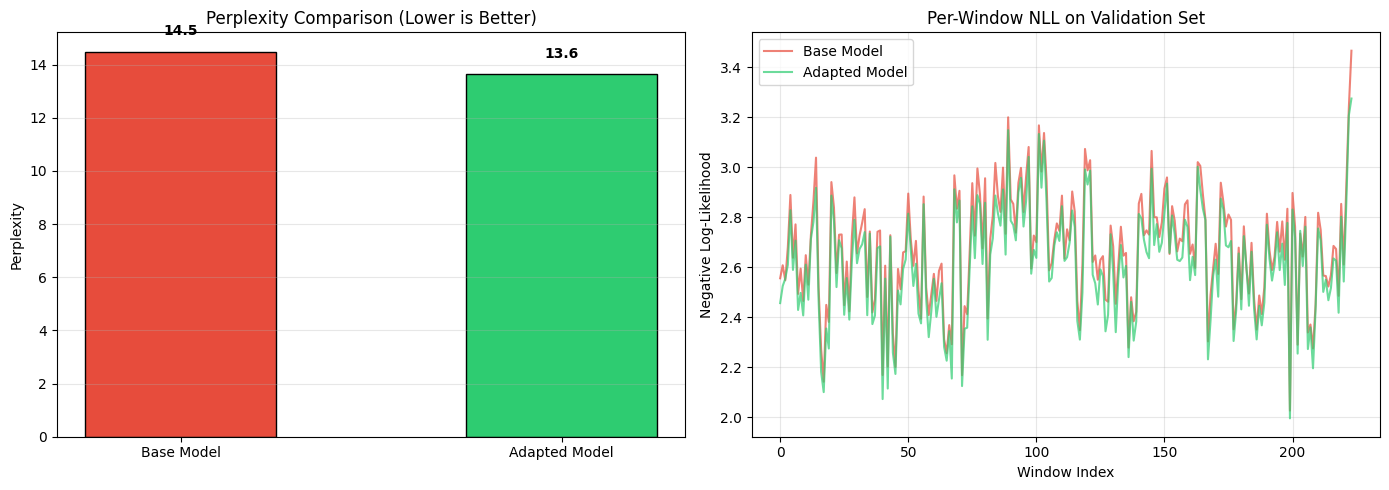

Saved: perplexity_comparison.png


In [10]:
# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Perplexity comparison bar chart
ax1 = axes[0]
models_compared = ['Base Model', 'Adapted Model']
ppls = [base_ppl, adapted_ppl]
colors = ['#e74c3c', '#2ecc71']
bars = ax1.bar(models_compared, ppls, color=colors, edgecolor='black', width=0.5)
ax1.set_ylabel('Perplexity')
ax1.set_title('Perplexity Comparison (Lower is Better)')
ax1.grid(True, alpha=0.3, axis='y')
for bar, ppl in zip(bars, ppls):
    ax1.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
             f'{ppl:.1f}', ha='center', va='bottom', fontweight='bold')

# Plot 2: Per-window NLL comparison
ax2 = axes[1]
ax2.plot(base_nlls, label='Base Model', alpha=0.7, color='#e74c3c')
ax2.plot(adapted_nlls, label='Adapted Model', alpha=0.7, color='#2ecc71')
ax2.set_xlabel('Window Index')
ax2.set_ylabel('Negative Log-Likelihood')
ax2.set_title('Per-Window NLL on Validation Set')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('perplexity_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: perplexity_comparison.png')

## 5. Qualitative Comparison — Text Generation

In [11]:
# Compare text generation between base and adapted models
prompts = [
    'Sherlock Holmes picked up the magnifying glass and',
    'Watson entered the room at 221B Baker Street and found',
    'The criminal had left a single clue:',
    '"Elementary, my dear Watson," said Holmes.',
]

print('=== Text Generation Comparison ===')
for prompt in prompts:
    print(f'\nPrompt: "{prompt}"')
    inputs = tokenizer(prompt, return_tensors='pt').to(device)
    
    # Base model generation
    with torch.no_grad():
        base_output = base_model.generate(
            **inputs, max_new_tokens=80, temperature=0.7,
            do_sample=True, top_p=0.9, repetition_penalty=1.1,
        )
    base_text = tokenizer.decode(base_output[0], skip_special_tokens=True)
    
    # Adapted model generation  
    with torch.no_grad():
        adapted_output = adapted_model.generate(
            **inputs, max_new_tokens=80, temperature=0.7,
            do_sample=True, top_p=0.9, repetition_penalty=1.1,
        )
    adapted_text = tokenizer.decode(adapted_output[0], skip_special_tokens=True)
    
    print(f'  Base:    {base_text}')
    print(f'  Adapted: {adapted_text}')
    print('-' * 80)

[transformers] Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.


=== Text Generation Comparison ===

Prompt: "Sherlock Holmes picked up the magnifying glass and"


c:\Users\BeRo074\OneDrive - HP Inc\Desktop\second_degree - BGU\LLM models\assignment1\venv\lib\site-packages\bitsandbytes\backends\cuda\ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
[transformers] Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.


  Base:    Sherlock Holmes picked up the magnifying glass and examined the letter.
"It is a very clever piece of work," said he, after having read it
through. "There are three lines which appear to be written in cipher."
He took out his pocket-book, opened it at his usual place for such
information, and drew from it the card containing the key.

"See here, Watson--a curious little note."

"You will make us both
  Adapted: Sherlock Holmes picked up the magnifying glass and examined it
carefully.

"It is not a common one," he said. "This was once used by Sir Arthur
Conway, who had many curious things of his own in the house."

I have never seen so fine an object in my life as this little thing.
The frame was made of silver, and the lens itself was like a jewel in
its own right. It shone
--------------------------------------------------------------------------------

Prompt: "Watson entered the room at 221B Baker Street and found"


[transformers] Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.


  Base:    Watson entered the room at 221B Baker Street and found Sherlock Holmes
standing by his desk with a newspaper in his hand.

"Good morning, Watson," said he. "I am glad to see you again."

"And I to you, my dear friend." He sat down on one of the chairs which
had been drawn together for the purpose of receiving the visitor.
Holmes was not much affected by the change of scene from the country
to London
  Adapted: Watson entered the room at 221B Baker Street and found Holmes in his study, a cigar
in his mouth and a book lying open upon the desk.

"What do you think of this one?" he asked.

"I don't like it," said Holmes. "The style is too modern for my taste."
He had turned over a few pages and was examining the title page, which bore
the name of Professor W. B. Watson, M.A.,
--------------------------------------------------------------------------------

Prompt: "The criminal had left a single clue:"


[transformers] Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.


  Base:    The criminal had left a single clue: the number of his
household servant.  This was at once taken into consideration by Holmes,
and he soon found it out that there were only three servants in this
family, and that they were all married to each other.

"Then we must try to find some one who is unmarried," said he.  "I
should like you to go round the neighbourhood with me for a few
  Adapted: The criminal had left a single clue: the
name of a certain Mr. Baker.

"This is an old-fashioned case," said Holmes, after I had told him
what had happened, "but it will lead us straight to the culprit."

He looked at me with his bright eyes, and then he drew back his lips,
and as if by calculation he made a slight motion with them toward the
wall behind which he was seated.


--------------------------------------------------------------------------------

Prompt: ""Elementary, my dear Watson," said Holmes."


[transformers] Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.


  Base:    "Elementary, my dear Watson," said Holmes. "I have just come out
of a case which will give me time to think over the puzzle of last
night's murder."

"What was it?"

"I am not quite certain myself. I should be able to tell you exactly
what happened if you would wait until we are alone together. The facts,
as far as I can remember them, were these: A gentleman named Mr.
Rid
  Adapted: "Elementary, my dear Watson," said Holmes. "It is the most simple of
mysteries."

He held his hand out to me.

"The clue," he explained, "is in your own hands. There are two sets of
keys which you may examine. The first key opens the door into the room,
the second leads through a small passage and gives access to the
subterranean cellar. By that way we shall reach the
--------------------------------------------------------------------------------


## 6. Save Results

In [12]:
# Save evaluation results
results = {
    'model_name': MODEL_NAME,
    'adapter_path': str(ADAPTER_PATH),
    'max_length': MAX_LENGTH,
    'stride': STRIDE,
    'val_tokens': val_tokens,
    'base_perplexity': float(base_ppl),
    'adapted_perplexity': float(adapted_ppl),
    'improvement_pct': float((base_ppl - adapted_ppl) / base_ppl * 100),
    'base_avg_nll': float(np.mean(base_nlls)),
    'adapted_avg_nll': float(np.mean(adapted_nlls)),
}

results_path = Path('outputs/evaluation_results.json')
with open(results_path, 'w') as f:
    json.dump(results, f, indent=2)

print(f'Results saved to: {results_path}')
print(json.dumps(results, indent=2))

Results saved to: outputs\evaluation_results.json
{
  "model_name": "Qwen/Qwen2.5-1.5B",
  "adapter_path": "outputs\\baseline\\final_adapter",
  "max_length": 512,
  "stride": 256,
  "val_tokens": 57478,
  "base_perplexity": 14.493626080420734,
  "adapted_perplexity": 13.648573134225582,
  "improvement_pct": 5.830514334412997,
  "base_avg_nll": 2.673708972121988,
  "adapted_avg_nll": 2.613634983875922
}
